# Advanced Statistical Analysis

This notebook covers RFM Customer Segmentation, K-Means Clustering, and Cohort Analysis.

In [ ]:

# Imports and setup

import sys
!{sys.executable} -m pip install pandas numpy matplotlib seaborn scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import timedelta
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)

  Using cached scikit_learn-1.8.0-cp311-cp311-macosx_10_9_x86_64.whl.metadata (11 kB)
  Using cached scipy-1.17.1-cp311-cp311-macosx_14_0_x86_64.whl.metadata (62 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached scikit_learn-1.8.0-cp311-cp311-macosx_10_9_x86_64.whl (8.6 MB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached scipy-1.17.1-cp311-cp311-macosx_14_0_x86_64.whl (22.7 MB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [scikit-learn] [scikit-learn]

[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: /usr/local/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip


In [ ]:

# Load the cleaned data
df = pd.read_csv('../data/processed/cleaned_data.csv')
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,InvoiceMonth,InvoiceYear
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30,12,2010
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,12,2010
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00,12,2010
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,12,2010
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,12,2010


### RFM Analysis
Recency, Frequency, and Monetary Value segmentation.

In [ ]:

# Calculate RFM Metrics

snapshot_date = df['InvoiceDate'].max() + timedelta(days=1)

# Aggregate data on CustomerID level
rfm = df.dropna(subset=['CustomerID']).groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'Revenue': 'sum'
}).reset_index()

rfm.rename(columns={
    'InvoiceDate': 'Recency',
    'InvoiceNo': 'Frequency',
    'Revenue': 'Monetary'
}, inplace=True)

rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12346,326,1,77183.60
1,12347,2,7,4310.00
2,12348,75,4,1797.24
3,12349,19,1,1757.55
4,12350,310,1,334.40


In [ ]:

# RFM Quartile Scoring

r_labels = range(4, 0, -1) # Recency: Lower is better (4 is best)
f_labels = range(1, 5)     # Frequency: Higher is better
m_labels = range(1, 5)     # Monetary: Higher is better

r_quartiles = pd.qcut(rfm['Recency'], q=4, labels=r_labels)
f_quartiles = pd.qcut(rfm['Frequency'].rank(method='first'), q=4, labels=f_labels)
m_quartiles = pd.qcut(rfm['Monetary'], q=4, labels=m_labels)

rfm = rfm.assign(R=r_quartiles, F=f_quartiles, M=m_quartiles)
rfm['RFM_Score'] = rfm[['R', 'F', 'M']].astype(str).agg(''.join, axis=1)

# Create segments based on R and F scores
def join_rfm(x): return str(x['R']) + str(x['F'])
rfm['RF_Segment'] = rfm.apply(join_rfm, axis=1)

rfm.head()

,CustomerID,Recency,Frequency,Monetary,R,F,M,RFM_Score,RF_Segment
0,12346,326,1,77183.60,1,1,4,114,11
1,12347,2,7,4310.00,4,4,4,444,44
2,12348,75,4,1797.24,2,3,4,234,23
3,12349,19,1,1757.55,3,1,4,314,31
4,12350,310,1,334.40,1,1,2,112,11


### K-Means Clustering
Using machine learning to find distinct customer groups based on RFM features.

In [ ]:

# Data Preprocessing for K-Means

# Handle right-skewed data with log transformation
# Adding 1 to avoid log(0)
rfm_log = rfm[['Recency', 'Frequency', 'Monetary']].apply(lambda x: np.log(x + 1))

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)
rfm_scaled = pd.DataFrame(rfm_scaled, index=rfm.index, columns=rfm_log.columns)

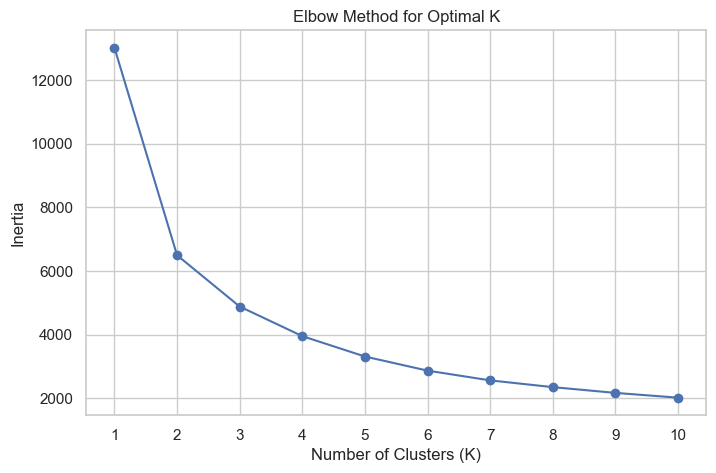

In [ ]:

# Determining Optimal K (Elbow Method)

inertia = []
k_range = range(1, 11)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.xticks(k_range)
plt.show()

In [ ]:

# Fit K-Means and Profile Clusters

# From the elbow plot, K=3 or 4 is a good choice. We use 4.
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

cluster_summary = rfm.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': ['mean', 'count']
}).round(1)

display(cluster_summary)

Recency Frequency Monetary      
           mean      mean     mean count
Cluster                                 
0          18.1       2.2    547.2   836
1          71.4       4.1   1779.9  1186
2          12.2      13.7   8059.2   717
3         183.1       1.3    337.7  1600

### Cohort Analysis
Tracking customer retention across acquisition months.

In [ ]:

# Prepare Cohort Data

def get_month(x): return x.replace(day=1, hour=0, minute=0, second=0)
df['InvoiceMonth'] = df['InvoiceDate'].apply(get_month)

grouping = df.dropna(subset=['CustomerID']).groupby('CustomerID')['InvoiceMonth']
df['CohortMonth'] = grouping.transform('min')
df = df.dropna(subset=['CohortMonth']) # Drop rows without customer IDs

def get_date_int(df, column):
    year = df[column].dt.year
    month = df[column].dt.month
    return year, month

invoice_year, invoice_month = get_date_int(df, 'InvoiceMonth')
cohort_year, cohort_month = get_date_int(df, 'CohortMonth')

years_diff = invoice_year - cohort_year
months_diff = invoice_month - cohort_month
df['CohortIndex'] = years_diff * 12 + months_diff + 1

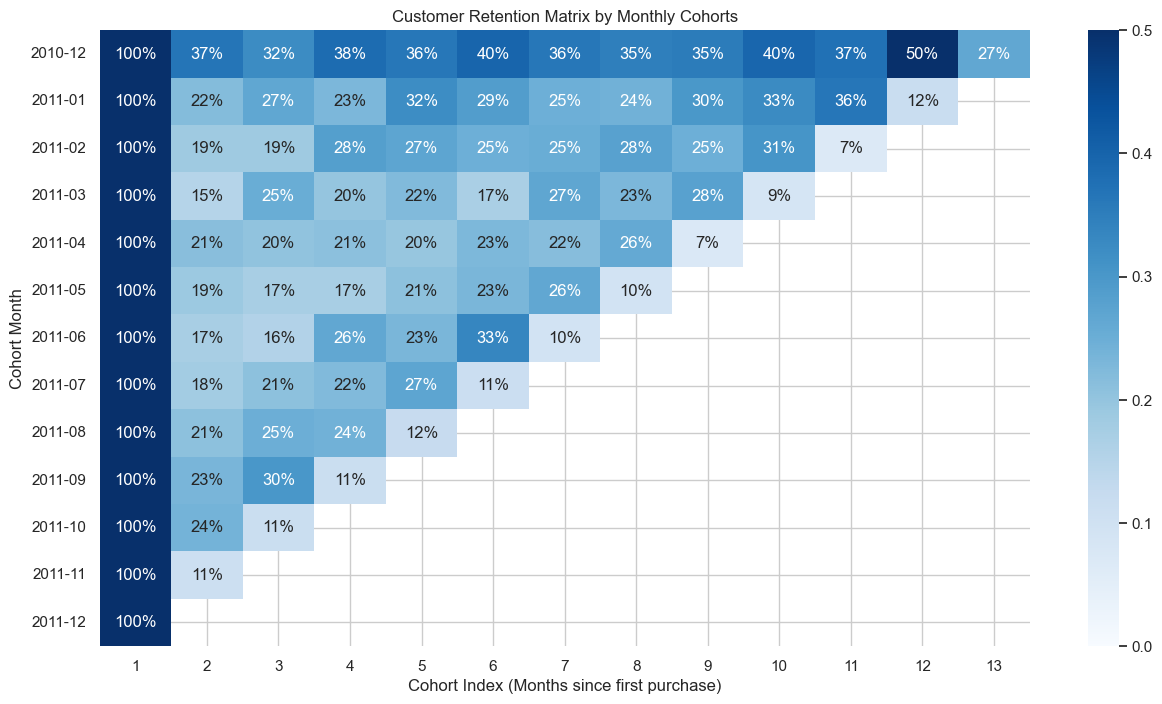

In [ ]:

# Calculate Retention Matrix

cohort_data = df.groupby(['CohortMonth', 'CohortIndex'])['CustomerID'].nunique().reset_index()
cohort_counts = cohort_data.pivot(index='CohortMonth', columns='CohortIndex', values='CustomerID')

cohort_sizes = cohort_counts.iloc[:,0]
retention = cohort_counts.divide(cohort_sizes, axis=0)

# Format the CohortMonth for better display
retention.index = retention.index.strftime('%Y-%m')

plt.figure(figsize=(15, 8))
sns.heatmap(data=retention, annot=True, fmt='.0%', cmap='Blues', vmin=0.0, vmax=0.5)
plt.title('Customer Retention Matrix by Monthly Cohorts')
plt.ylabel('Cohort Month')
plt.xlabel('Cohort Index (Months since first purchase)')
plt.show()